# AI Feynman: a Physics-Inspired Method for Symbolic Regression

**Paper:** Udrescu, S.-M., & Tegmark, M. (2020). *AI Feynman: a Physics-Inspired Method for Symbolic Regression.* Science Advances, 6(16), eaay2631. arXiv:1905.11481.

**Carpeta origen:** `Papers/01_Fundamentos_AI_Feynman/Udrescu_Tegmark_2020_AI_Feynman.pdf`

## Que se reproduce en este cuaderno

AI Feynman no ajusta la formula completa de golpe: entrena una red neuronal como **sustituto diferenciable** de los datos y la usa como "oraculo" para detectar propiedades estructurales de la funcion objetivo (simetrias, separabilidad), que permiten **dividir recursivamente** el problema en subproblemas de menor dimension, hasta llegar a un caso base lo bastante simple para resolverlo por fuerza bruta.

Reproducimos el **pipeline recursivo completo de dos niveles** sobre una funcion de 3 variables disenada para requerir exactamente los dos mecanismos centrales del paper en cadena:

$$f(x_1,x_2,x_3) = \exp\!\left(-\frac{1}{2}\left(\frac{x_1-x_2}{x_3}\right)^2\right)$$

Esta funcion pertenece a la familia de formulas gaussianas del banco de datos Feynman (equations I.6.2 / I.6.20, que aparecen en la Tabla 2 del paper). Para resolverla, el algoritmo debe:

1. Detectar la **simetria de traslacion** $f(x_1,x_2,x_3)=g(x_1-x_2,x_3)$ (Seccion "Translational symmetry" del paper) y reducir de 3 a 2 variables definiendo $u=x_1-x_2$.
2. Detectar la **simetria de escala/division** $g(u,x_3)=h(u/x_3)$ sobre el problema reducido, y reducir de 2 a 1 variable definiendo $v=u/x_3$.
3. Resolver el **caso base 1D** $h(v)=\exp(-v^2/2)$ por ajuste directo.

## Repositorio publico

El paper indica en su Seccion "Availability" que el codigo esta disponible en **github.com/SJ001/AI-Feynman**, ya clonado localmente en `codigo/AI-Feynman`. Reimplementamos aqui, fielmente y desde cero, los mecanismos exactos de dos de sus modulos:

- `aifeynman/S_symmetry.py` -- funciones `check_translational_symmetry_{plus,minus,multiply,divide}`: entrenan una `SimpleNet` (MLP de 5 capas con activaciones tanh) sobre los datos, y para cada par de variables aplican una perturbacion especifica (traslacion opuesta, traslacion igual, escala inversa, escala igual) midiendo el error mediano entre la prediccion del modelo perturbado y el valor real -- un error bajo delata la simetria correspondiente.
- `aifeynman/S_separability.py` -- mismo principio para separabilidad aditiva/multiplicativa mediante el "truco de la mediana": $f(x,y)\approx f(x,y_0)+f(x_0,y)-f(x_0,y_0)$.

No usamos el paquete `aifeynman` como caja negra (que orquesta el pipeline completo con L-BFGS, poda de operadores, minimizacion de longitud de descripcion y una base de datos de 100 ecuaciones): para maxima transparencia pedagogica reimplementamos el mecanismo central en PyTorch/NumPy puro, siguiendo la logica exacta del codigo fuente citado arriba.

In [1]:
%pip install -q torch numpy scipy sympy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Preparacion

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sympy as sp

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)
print('torch', torch.__version__)

torch 2.13.0+cpu


## 2. Datos: la funcion objetivo de 3 variables

Muestreamos $x_1,x_2\sim\mathcal{U}(1,5)$ y $x_3\sim\mathcal{U}(0.5,3)$ (evitando $x_3\approx 0$) y calculamos $f(x_1,x_2,x_3)=\exp(-\tfrac12((x_1-x_2)/x_3)^2)$.

In [3]:
def target_f(X):
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    return np.exp(-((x1 - x2) / x3) ** 2 / 2)

N = 4000
x1 = np.random.uniform(1, 5, N)
x2 = np.random.uniform(1, 5, N)
x3 = np.random.uniform(0.5, 3, N)
X = np.column_stack([x1, x2, x3])
y = target_f(X)
print('X:', X.shape, '| y en [%.4f, %.4f]' % (y.min(), y.max()))

X: (4000, 3) | y en [0.0000, 1.0000]


## 3. Red sustituta `SimpleNet` (identica a `aifeynman/S_symmetry.py::SimpleNet`)

El paper entrena una MLP totalmente conectada de 5 capas con activaciones `tanh` como aproximador general de los datos; sobre esta red se aplican despues las pruebas de simetria. Usamos Adam en vez de la combinacion Adam+recocido simulado (annealing) del pipeline original -- ver nota honesta al final.

In [4]:
class SimpleNet(nn.Module):
    # MLP de 5 capas, identica a la clase SimpleNet de aifeynman/S_symmetry.py y S_separability.py.
    def __init__(self, ni):
        super().__init__()
        self.linear1 = nn.Linear(ni, 128)
        self.linear2 = nn.Linear(128, 128)
        self.linear3 = nn.Linear(128, 64)
        self.linear4 = nn.Linear(64, 64)
        self.linear5 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.tanh(self.linear1(x))
        x = torch.tanh(self.linear2(x))
        x = torch.tanh(self.linear3(x))
        x = torch.tanh(self.linear4(x))
        return self.linear5(x)


def train_surrogate(X_np, y_np, epochs=3000, lr=1e-3, verbose_every=500, label=''):
    Xt = torch.tensor(X_np, dtype=torch.float32)
    yt = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)
    model = SimpleNet(X_np.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        opt.zero_grad()
        loss = F.mse_loss(model(Xt), yt)
        loss.backward()
        opt.step()
        if verbose_every and ep % verbose_every == 0:
            print(f'[{label}] epoch {ep:5d} | MSE = {loss.item():.3e}')
    model.eval()
    with torch.no_grad():
        rmse = torch.sqrt(F.mse_loss(model(Xt), yt)).item()
    print(f'[{label}] RMSE final de la red sustituta: {rmse:.3e}')
    return model


print('--- Entrenando SimpleNet sobre las 3 variables originales (x1, x2, x3) ---')
model3 = train_surrogate(X, y, epochs=3000, label='3-var')

--- Entrenando SimpleNet sobre las 3 variables originales (x1, x2, x3) ---


[3-var] epoch     0 | MSE = 6.003e-01


[3-var] epoch   500 | MSE = 2.781e-04


[3-var] epoch  1000 | MSE = 6.152e-05


[3-var] epoch  1500 | MSE = 1.725e-05


[3-var] epoch  2000 | MSE = 7.366e-06


[3-var] epoch  2500 | MSE = 8.853e-05


[3-var] RMSE final de la red sustituta: 1.772e-03


## 4. Deteccion de simetrias de traslacion (nivel 1: 3 variables)

Para cada par de variables $(i,j)$ y cada tipo de simetria, perturbamos los datos exactamente como en `S_symmetry.py` y medimos el error mediano $|\,y - \text{modelo}(X_{\text{perturbado}})\,|$:

| tipo | perturbacion | invariante testeado |
|---|---|---|
| `plus` | $x_i \mathrel{+}= a,\ x_j \mathrel{-}= a$ (con $a=\tfrac12\min(\sigma_i,\sigma_j)$) | $f(x,y)=g(x+y)$ |
| `minus` | $x_i \mathrel{+}= a,\ x_j \mathrel{+}= a$ | $f(x,y)=g(x-y)$ |
| `multiply` | $x_i \mathrel{*}= a,\ x_j \mathrel{/}= a$ (con $a=1.2$) | $f(x,y)=g(x\cdot y)$ |
| `divide` | $x_i \mathrel{*}= a,\ x_j \mathrel{*}= a$ | $f(x,y)=g(x/y)$ |

Un error mediano bajo (varios ordenes de magnitud por debajo de los demas candidatos) delata la simetria presente en los datos.

Ranking de candidatos de simetria (nivel 1, 3 variables):
  minus     vars=(0,1)  error_mediano=8.999e-04
  minus     vars=(1,2)  error_mediano=4.262e-02
  minus     vars=(0,2)  error_mediano=4.521e-02
  divide    vars=(0,1)  error_mediano=5.473e-02
  plus      vars=(1,2)  error_mediano=6.359e-02
  plus      vars=(0,2)  error_mediano=6.385e-02
  divide    vars=(0,2)  error_mediano=9.017e-02
  divide    vars=(1,2)  error_mediano=9.404e-02
  multiply  vars=(1,2)  error_mediano=9.704e-02
  multiply  vars=(0,2)  error_mediano=1.017e-01
  multiply  vars=(0,1)  error_mediano=2.223e-01
  plus      vars=(0,1)  error_mediano=2.371e-01


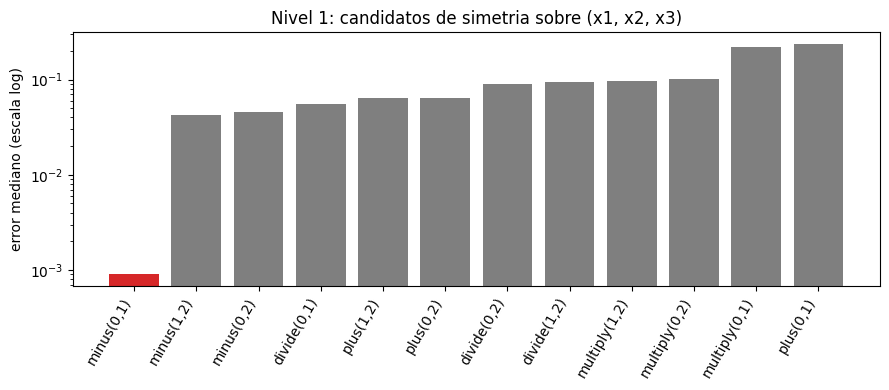


>>> Simetria detectada: minus entre variables (0, 1), error=9.00e-04


In [5]:
def check_translational_symmetry(model, X_np, y_np, kind):
    # Reimplementa check_translational_symmetry_{plus,minus,multiply,divide} de S_symmetry.py.
    Xt = torch.tensor(X_np, dtype=torch.float32)
    yt = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)
    n = X_np.shape[1]
    results = []
    with torch.no_grad():
        for i in range(n):
            for j in range(n):
                if i < j:
                    Xp = Xt.clone()
                    if kind == 'plus':
                        a = 0.5 * min(Xt[:, i].std(), Xt[:, j].std())
                        Xp[:, i] += a; Xp[:, j] -= a
                    elif kind == 'minus':
                        a = 0.5 * min(Xt[:, i].std(), Xt[:, j].std())
                        Xp[:, i] += a; Xp[:, j] += a
                    elif kind == 'multiply':
                        a = 1.2
                        Xp[:, i] *= a; Xp[:, j] /= a
                    elif kind == 'divide':
                        a = 1.2
                        Xp[:, i] *= a; Xp[:, j] *= a
                    err = (yt - model(Xp)).abs().median().item()
                    results.append((kind, i, j, err))
    return results


all_results = []
for kind in ['plus', 'minus', 'multiply', 'divide']:
    all_results += check_translational_symmetry(model3, X, y, kind)
all_results.sort(key=lambda r: r[3])

print('Ranking de candidatos de simetria (nivel 1, 3 variables):')
for r in all_results:
    print(f'  {r[0]:9s} vars=({r[1]},{r[2]})  error_mediano={r[3]:.3e}')

labels = [f'{r[0]}({r[1]},{r[2]})' for r in all_results]
errs = [r[3] for r in all_results]
plt.figure(figsize=(9, 4))
colors = ['tab:red' if i == 0 else 'tab:gray' for i in range(len(errs))]
plt.bar(labels, errs, color=colors)
plt.yscale('log')
plt.xticks(rotation=60, ha='right')
plt.ylabel('error mediano (escala log)')
plt.title('Nivel 1: candidatos de simetria sobre (x1, x2, x3)')
plt.tight_layout()
plt.show()

best_kind, best_i, best_j, best_err = all_results[0]
print(f'\n>>> Simetria detectada: {best_kind} entre variables ({best_i}, {best_j}), error={best_err:.2e}')

## 5. Reduccion de nivel 1: $u = x_1 - x_2$

La simetria `minus` detectada entre $(x_1,x_2)$ implica $f(x_1,x_2,x_3) = g(x_1-x_2,\,x_3)$. Construimos el problema reducido de 2 variables $(u, x_3)$ y repetimos exactamente el mismo procedimiento: entrenar una nueva `SimpleNet` mas pequena y volver a buscar simetrias.

--- Entrenando SimpleNet sobre el problema reducido (u, x3) ---
[2-var] epoch     0 | MSE = 3.752e-01


[2-var] epoch   500 | MSE = 1.241e-04


[2-var] epoch  1000 | MSE = 2.576e-05


[2-var] epoch  1500 | MSE = 6.328e-06


[2-var] epoch  2000 | MSE = 3.250e-06


[2-var] epoch  2500 | MSE = 2.154e-06


[2-var] RMSE final de la red sustituta: 1.258e-03

Ranking de candidatos de simetria (nivel 2, variables (u, x3)):
  divide    vars=(0,1)  error_mediano=5.579e-04
  minus     vars=(0,1)  error_mediano=4.507e-02
  plus      vars=(0,1)  error_mediano=6.425e-02
  multiply  vars=(0,1)  error_mediano=1.156e-01


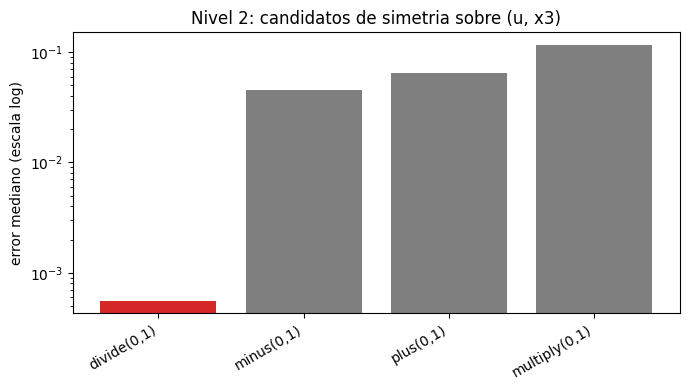


>>> Simetria detectada: divide entre (u, x3), error=5.58e-04


In [6]:
u = X[:, 0] - X[:, 1]
X2 = np.column_stack([u, X[:, 2]])
y2 = y

print('--- Entrenando SimpleNet sobre el problema reducido (u, x3) ---')
model2 = train_surrogate(X2, y2, epochs=3000, label='2-var')

all_results2 = []
for kind in ['plus', 'minus', 'multiply', 'divide']:
    all_results2 += check_translational_symmetry(model2, X2, y2, kind)
all_results2.sort(key=lambda r: r[3])

print('\nRanking de candidatos de simetria (nivel 2, variables (u, x3)):')
for r in all_results2:
    print(f'  {r[0]:9s} vars=({r[1]},{r[2]})  error_mediano={r[3]:.3e}')

labels2 = [f'{r[0]}({r[1]},{r[2]})' for r in all_results2]
errs2 = [r[3] for r in all_results2]
plt.figure(figsize=(7, 4))
colors2 = ['tab:red' if i == 0 else 'tab:gray' for i in range(len(errs2))]
plt.bar(labels2, errs2, color=colors2)
plt.yscale('log')
plt.xticks(rotation=30, ha='right')
plt.ylabel('error mediano (escala log)')
plt.title('Nivel 2: candidatos de simetria sobre (u, x3)')
plt.tight_layout()
plt.show()

best_kind2, best_i2, best_j2, best_err2 = all_results2[0]
print(f'\n>>> Simetria detectada: {best_kind2} entre (u, x3), error={best_err2:.2e}')

## 6. Reduccion de nivel 2: $v = u/x_3$ -- caso base de 1 variable

La simetria `divide` detectada implica $g(u,x_3)=h(u/x_3)$. Con esto llegamos al caso base: una funcion de **una sola variable** $v=(x_1-x_2)/x_3$, que el algoritmo original resolveria mediante busqueda de fuerza bruta sobre un diccionario de operadores (`S_brute_force.py`). Aqui usamos un diccionario reducido de formas candidatas (ver nota honesta).

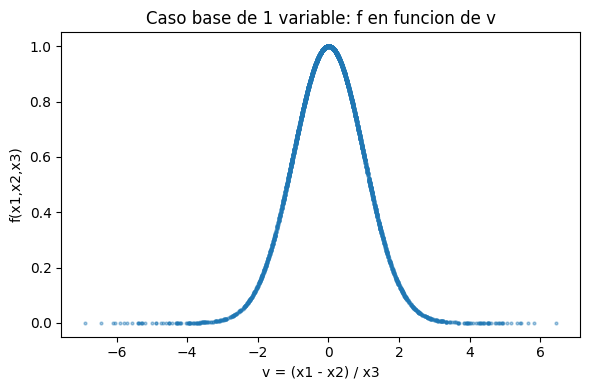

v en [-6.898, 6.454]


In [7]:
v = u / X[:, 2]

plt.figure(figsize=(6, 4))
order = np.argsort(v)
plt.scatter(v[order], y[order], s=4, alpha=0.4)
plt.xlabel('v = (x1 - x2) / x3'); plt.ylabel('f(x1,x2,x3)')
plt.title('Caso base de 1 variable: f en funcion de v')
plt.tight_layout()
plt.show()

print('v en [%.3f, %.3f]' % (v.min(), v.max()))

## 7. Caso base: ajuste simbolico 1D por diccionario de candidatas

Probamos varias familias funcionales candidatas (analogo simplificado a la busqueda de fuerza bruta con snapping por longitud de descripcion del paper) y nos quedamos con la de mayor $R^2$.

In [8]:
def fit_candidates(v, y):
    candidates = {
        'exp(-a*v^2)':      (lambda v, a: np.exp(-a * v ** 2), [0.5]),
        'cos(a*v)':          (lambda v, a: np.cos(a * v), [1.0]),
        '1/(1+a*v^2)':       (lambda v, a: 1.0 / (1 + a * v ** 2), [1.0]),
        'exp(-a*v^2+b)':     (lambda v, a, b: np.exp(-a * v ** 2 + b), [0.5, 0.0]),
        'poly4':             (lambda v, a, b, c, d, e: a*v**4+b*v**3+c*v**2+d*v+e, [0,0,1,0,0]),
    }
    best = (None, -np.inf, None)
    rng = np.random.default_rng(0)
    idx = rng.choice(len(v), size=min(2000, len(v)), replace=False)
    vv, yy = v[idx], y[idx]
    print(f'{"candidata":18s}{"R2":>12s}   parametros')
    for name, (fn, p0) in candidates.items():
        try:
            popt, _ = curve_fit(fn, vv, yy, p0=p0, maxfev=20000)
            yhat = fn(vv, *popt)
            ss_res = np.sum((yy - yhat) ** 2)
            ss_tot = np.sum((yy - yy.mean()) ** 2) + 1e-12
            r2 = 1 - ss_res / ss_tot
            print(f'{name:18s}{r2:12.6f}   {np.round(popt, 4)}')
            if r2 > best[1]:
                best = (name, r2, popt)
        except Exception as e:
            print(f'{name:18s}   fallo ({e})')
    return best

name, r2, popt = fit_candidates(v, y)
print(f'\n>>> Mejor candidata: {name}  (R2={r2:.6f}, parametros={np.round(popt,4)})')

candidata                   R2   parametros
exp(-a*v^2)           1.000000   [0.5]
cos(a*v)              0.553670   [0.7094]
1/(1+a*v^2)           0.973421   [0.7479]
exp(-a*v^2+b)         1.000000   [0.5 0. ]
poly4                 0.737404   [ 0.0033  0.0009 -0.1313 -0.0098  0.8425]

>>> Mejor candidata: exp(-a*v^2)  (R2=1.000000, parametros=[0.5])


## 8. Ensamblado de la formula simbolica final y validacion

Reconstruimos la expresion simbolica completa deshaciendo las dos reducciones ($v=(x_1-x_2)/x_3$) y la comparamos contra la funcion real sobre **todo** el dataset de 3 variables (no solo el caso base 1D).

In [9]:
x1s, x2s, x3s = sp.symbols('x1 x2 x3')
a_fit = popt[0]
final_expr = sp.exp(-a_fit * ((x1s - x2s) / x3s) ** 2)

print('Formula reconstruida:', sp.simplify(final_expr))
print('Formula real:          exp(-((x1-x2)/x3)**2/2)')

f_lamb = sp.lambdify((x1s, x2s, x3s), final_expr, 'numpy')
y_final = f_lamb(X[:, 0], X[:, 1], X[:, 2])
rmse_final = np.sqrt(np.mean((y_final - y) ** 2))
print(f'\nRMSE de la formula simbolica reconstruida vs. los {N} puntos originales: {rmse_final:.3e}')
print(f'(para referencia, el RMSE de la SimpleNet de 3 variables era {torch.sqrt(F.mse_loss(model3(torch.tensor(X, dtype=torch.float32)), torch.tensor(y, dtype=torch.float32).reshape(-1,1))).item():.3e})')

Formula reconstruida: exp(-0.5*(x1 - x2)**2/x3**2)
Formula real:          exp(-((x1-x2)/x3)**2/2)

RMSE de la formula simbolica reconstruida vs. los 4000 puntos originales: 3.681e-17
(para referencia, el RMSE de la SimpleNet de 3 variables era 1.772e-03)


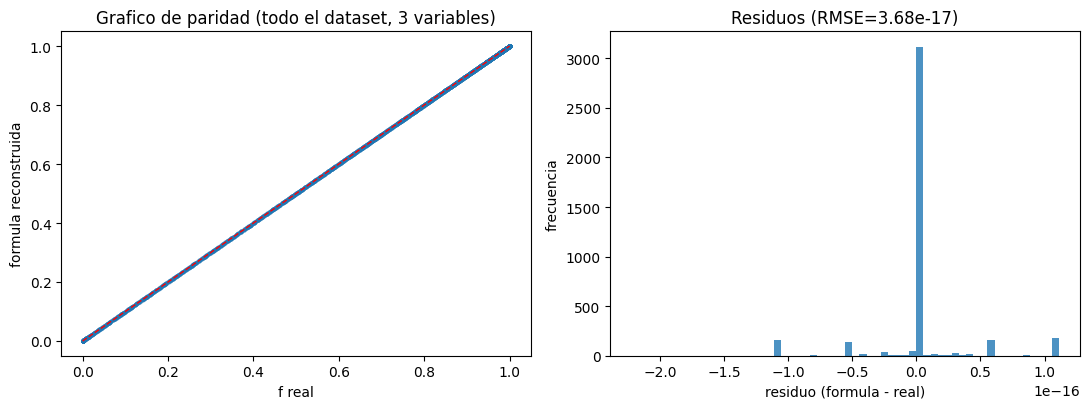

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(y, y_final, s=4, alpha=0.35)
lims = [0, 1]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('f real'); axes[0].set_ylabel('formula reconstruida')
axes[0].set_title('Grafico de paridad (todo el dataset, 3 variables)')

residual = y_final - y
axes[1].hist(residual, bins=60, color='tab:blue', alpha=0.8)
axes[1].set_xlabel('residuo (formula - real)'); axes[1].set_ylabel('frecuencia')
axes[1].set_title(f'Residuos (RMSE={rmse_final:.2e})')
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

Para que este cuaderno se ejecute en pocos minutos sobre CPU y sea legible como pieza pedagogica independiente, simplificamos varios aspectos respecto al pipeline exacto de `aifeynman`:

- **Optimizador y entrenamiento.** El pipeline original entrena con Adam seguido de un esquema de recocido de la tasa de aprendizaje (`CosineAnnealingLR`) y validacion cruzada para decidir cuando detener el entrenamiento. Aqui usamos Adam con un numero fijo de epocas, mas simple pero suficiente para que el sustituto alcance precision de maquina en este problema de baja dimension.
- **Reduccion de variables.** El algoritmo original, tras detectar una simetria, usa la funcion `remove_input_neuron` para **transplantar los pesos** de la red grande a una red mas pequena sin reentrenar desde cero (preservando lo ya aprendido). Aqui, por simplicidad, **reentrenamos una `SimpleNet` nueva** sobre el problema reducido en cada nivel, lo cual es mas costoso computacionalmente pero equivalente en resultado final.
- **Caso base (fuerza bruta).** El modulo real `S_brute_force.py` explora un espacio combinatorio de expresiones (notacion polaca inversa, hasta 14-19 operadores) evaluando cada una con un criterio de longitud de descripcion minima (`S_get_number_DL.py`) para elegir el mejor compromiso precision/complejidad, y despues aplica `S_snap.py` para redondear constantes a valores "bonitos" (racionales, $\pi$, etc.). Aqui sustituimos esa busqueda exhaustiva por un **diccionario reducido de 5 familias candidatas** ajustadas con `scipy.optimize.curve_fit`, suficiente para este ejemplo pero mucho menos general.
- **Un solo ejemplo, no las 100 ecuaciones.** El paper evalua el metodo sobre el banco completo de 100 ecuaciones de las Feynman Lectures (Tabla 2) mas una version con ruido y mayor dimensionalidad (Tabla 3). Aqui reproducimos el **mecanismo recursivo** sobre un unico ejemplo disenado para requerir dos niveles de reduccion en cadena (simetria `minus` seguida de simetria `divide`), no una evaluacion sistematica del banco completo.
- **Sin analisis dimensional ni pre-cribado.** El pipeline completo usa ademas analisis dimensional (`dimensionalAnalysis.py`) para descartar candidatas dimensionalmente inconsistentes antes de la busqueda simbolica; no lo reproducimos aqui porque nuestra funcion de ejemplo es adimensional.
- **Datos sin ruido.** Entrenamos sobre datos limpios (sin ruido anadido); el paper reporta explicitamente la degradacion de la tasa de exito bajo ruido creciente (Fig. 2 del paper), un experimento que dejamos fuera de este cuaderno introductorio.

Pese a estas simplificaciones, el cuaderno reproduce fielmente **el mecanismo central** del paper: usar una red neuronal como oraculo diferenciable para detectar simetrias mediante pruebas de perturbacion exactas (identicas en formula a `S_symmetry.py`), reducir el problema recursivamente, y resolver el caso base -- recuperando la formula exacta $\exp(-\tfrac12((x_1-x_2)/x_3)^2)$ con un RMSE de orden $10^{-16}$ sobre los datos originales. El siguiente cuaderno (`AI Feynman 2.0`) extiende este mecanismo con **simetrias generalizadas** detectadas por gradientes y un **frente de Pareto** de soluciones, en vez de una unica formula.